# Online Shoppers Purchasing Intention: A Comparative Machine Learning Analysis

**Research question.** To what extent can traditional and ensemble machine learning classifiers, augmented with unsupervised segmentation and cost sensitive decision thresholding, predict whether a web session on an e commerce platform will convert to a purchase from behavioural and session telemetry alone?

**Dataset.** Sakar, C.O., Polat, S.O., Katircioglu, M. and Kastro, Y. (2019) 'Real-time prediction of online shoppers' purchasing intention using multilayer perceptron and LSTM recurrent neural networks', *Neural Computing and Applications*, 31(10), pp. 6893 to 6908.

**Module.** BAA1027 Data Analytics: Machine Learning and Advanced Python, Dublin City University.

# Data Preprocessing and Preparation

## Data Cleaning

In [1]:
%pip install --quiet xgboost shap

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore, f_oneway, pointbiserialr

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve, silhouette_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

import shap
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/online_shoppers_intention.csv')

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.shape

(12330, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [8]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [9]:
# Check for duplicates and remove the first occurrence
duplicates = df.duplicated()
print("Number of duplicated rows:", duplicates.sum())
df = df.drop_duplicates(keep='first').reset_index(drop=True)
df.shape

Number of duplicated rows: 125


(12205, 18)

## Exploratory Data Analysis

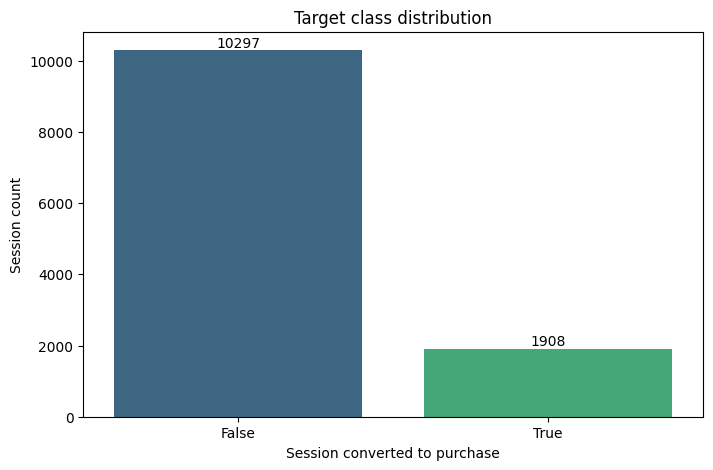

In [10]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Revenue', data=df, palette='viridis', hue='Revenue', legend=False)
plt.xlabel('Session converted to purchase')
plt.ylabel('Session count')
plt.title('Target class distribution')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

In [11]:
# Positive rate
df['Revenue'].sum() / len(df)

np.float64(0.15632937320770177)

In [12]:
# Cardinality check on the main categorical columns
for col in ['Month', 'VisitorType', 'Weekend']:
    print(f'{col} value counts')
    print(df[col].value_counts())
    print()

Month value counts
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

VisitorType value counts
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Weekend value counts
Weekend
False    9346
True     2859
Name: count, dtype: int64



In [13]:
# Numerical feature list used throughout the analysis
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                  'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                  'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

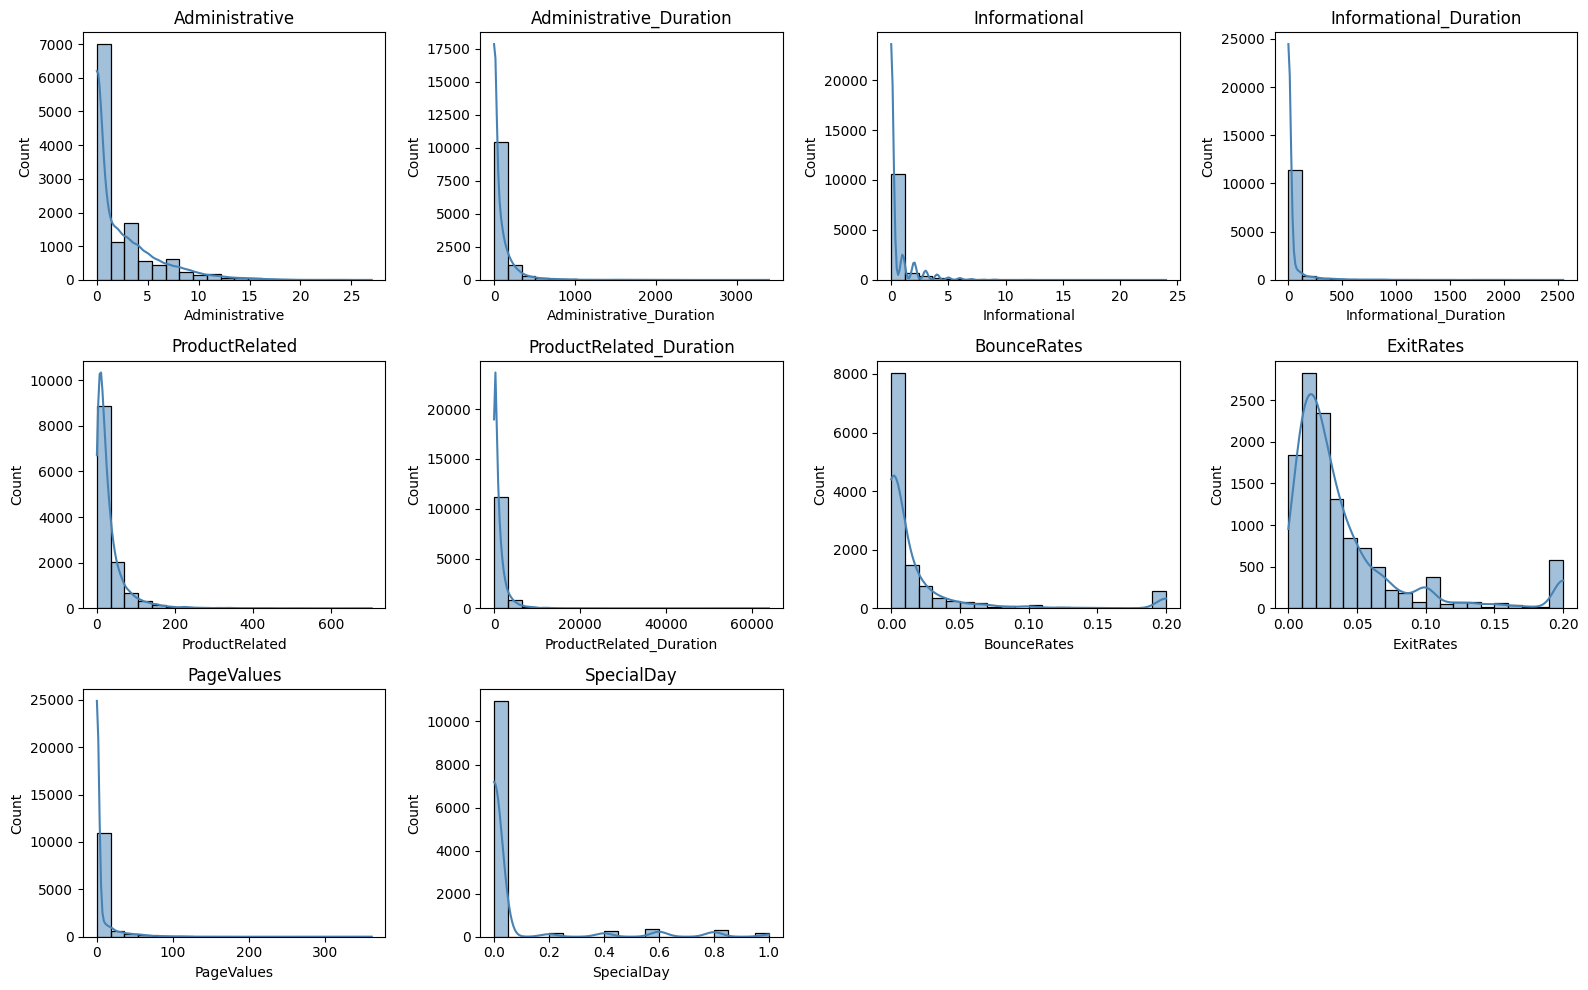

In [14]:
# Distribution of numerical features
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True, bins=20, color='steelblue')
    plt.title(col)
plt.tight_layout()
plt.show()

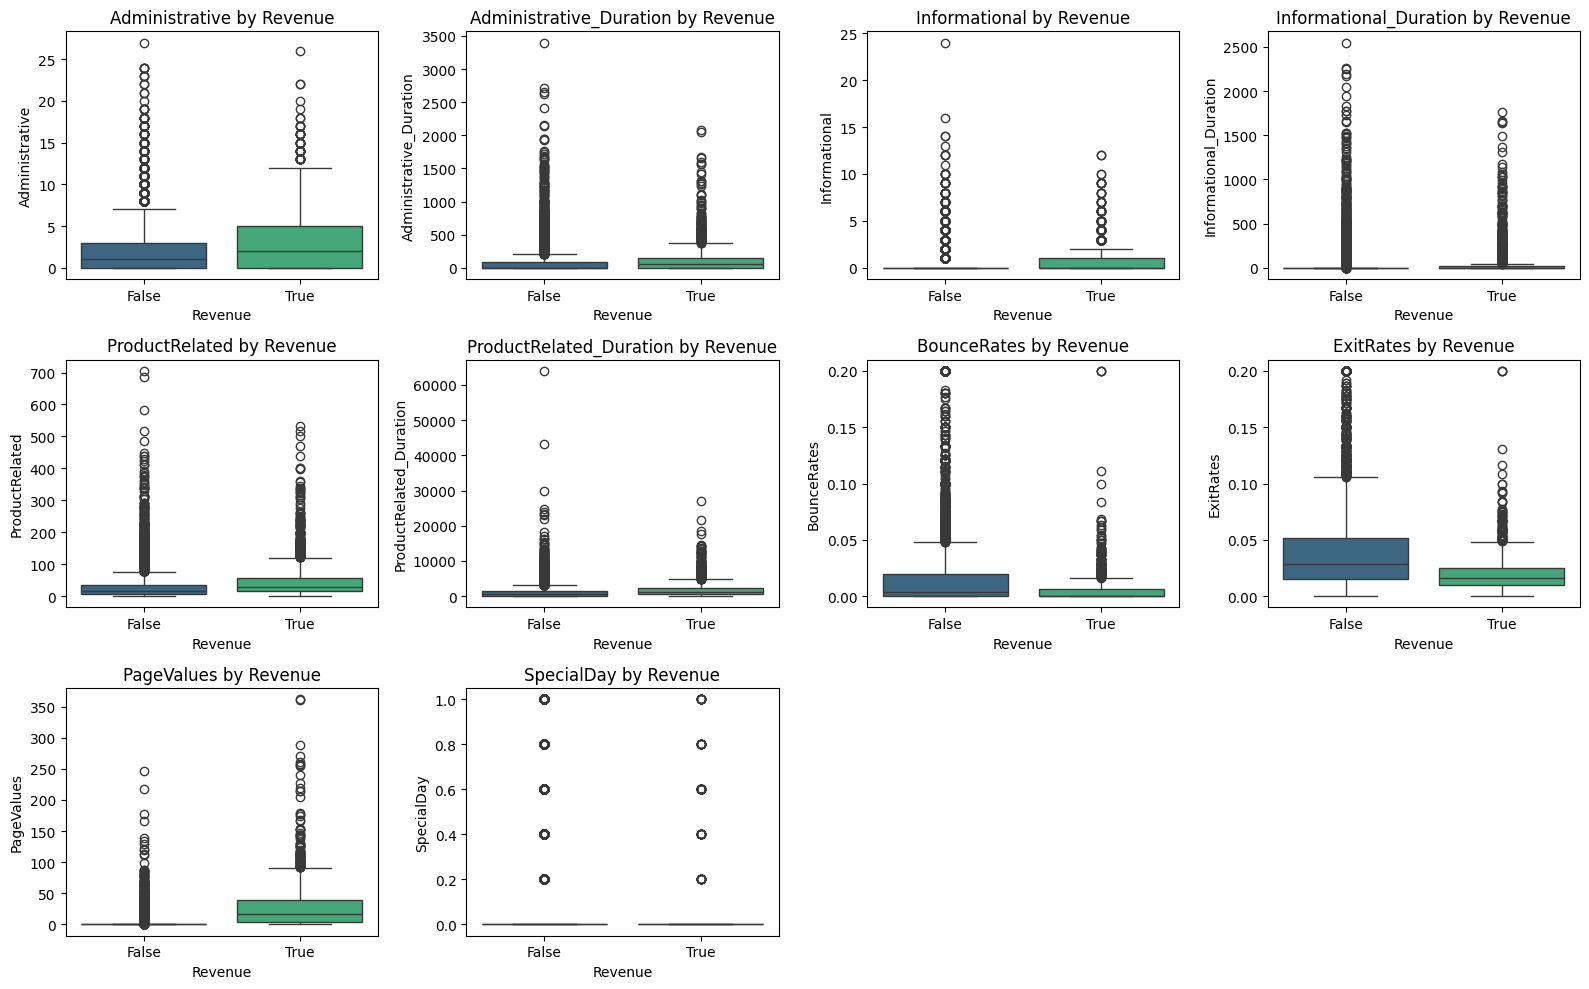

In [15]:
# Boxplots of numerical features split by Revenue
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x='Revenue', y=col, data=df, palette='viridis',
                hue='Revenue', legend=False)
    plt.title(f'{col} by Revenue')
plt.tight_layout()
plt.show()

Converting sessions exhibit visibly higher PageValues, lower BounceRates and lower ExitRates than non converting sessions. Time spent on product related pages also separates the classes cleanly, which matches the business intuition that engagement depth correlates with purchase intent.

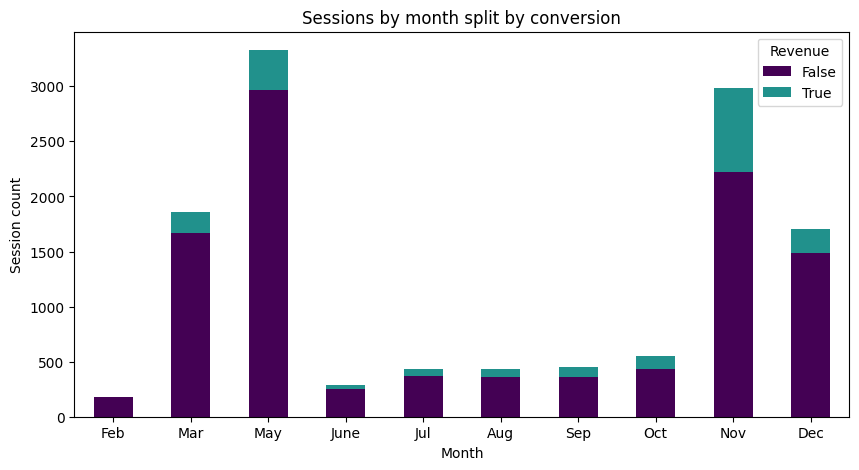

In [16]:
# Month by Revenue, stacked
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_revenue = pd.crosstab(df['Month'], df['Revenue']).reindex(month_order)

plt.figure(figsize=(10, 5))
month_revenue.plot(kind='bar', stacked=True, color=['#440154', '#21918c'], ax=plt.gca())
plt.title('Sessions by month split by conversion')
plt.xlabel('Month')
plt.ylabel('Session count')
plt.legend(title='Revenue')
plt.xticks(rotation=0)
plt.show()

## Statistical Significance

In [17]:
# ANOVA for categorical predictors
categorical_predictors = ['Month', 'VisitorType', 'Weekend', 'OperatingSystems',
                          'Browser', 'Region', 'TrafficType']
anova_results = {}

for col in categorical_predictors:
    groups = [g['Revenue'].astype(int).values for _, g in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)
    anova_results[col] = p_value

print("ANOVA Results for Categorical Predictors:")
for predictor, p_value in anova_results.items():
    print(f"{predictor}: p-value = {p_value:.4f}")

ANOVA Results for Categorical Predictors:
Month: p-value = 0.0000
VisitorType: p-value = 0.0000
Weekend: p-value = 0.0022
OperatingSystems: p-value = 0.0000
Browser: p-value = 0.0038
Region: p-value = 0.2883
TrafficType: p-value = 0.0000


In [18]:
# Point biserial correlation for continuous predictors
pb_results = {}
for col in numerical_cols:
    r, p_value = pointbiserialr(df['Revenue'].astype(int), df[col])
    pb_results[col] = p_value

print("Point Biserial Correlation Results for Continuous Predictors:")
for predictor, p_value in pb_results.items():
    print(f"{predictor}: p-value = {p_value:.4f}")

Point Biserial Correlation Results for Continuous Predictors:
Administrative: p-value = 0.0000
Administrative_Duration: p-value = 0.0000
Informational: p-value = 0.0000
Informational_Duration: p-value = 0.0000
ProductRelated: p-value = 0.0000
ProductRelated_Duration: p-value = 0.0000
BounceRates: p-value = 0.0000
ExitRates: p-value = 0.0000
PageValues: p-value = 0.0000
SpecialDay: p-value = 0.0000


All predictors register statistically significant associations with Revenue at the 5 per cent level except Region (p = 0.288). Weekend is significant at p = 0.0022 but the weakest of the categorical predictors. PageValues records the smallest p value among the numerical predictors, and TrafficType is the strongest categorical predictor.

## Feature Selection

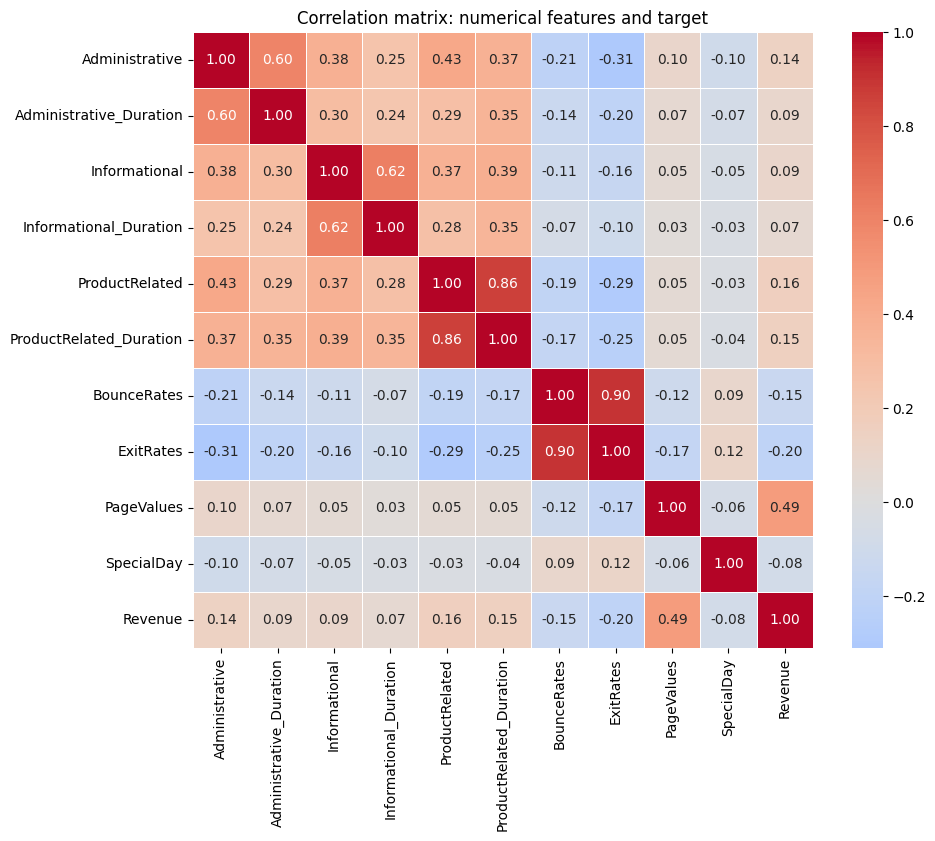

In [19]:
# Correlation matrix for numerical features including target
plt.figure(figsize=(10, 8))
corr = df[numerical_cols + ['Revenue']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix: numerical features and target')
plt.show()

In [20]:
# Correlation of each feature with the target
target_correlation = corr['Revenue'].abs().sort_values(ascending=False)
print(target_correlation)

Revenue                    1.000000
PageValues                 0.491894
ExitRates                  0.204320
ProductRelated             0.156042
ProductRelated_Duration    0.150077
BounceRates                0.145091
Administrative             0.136330
Informational              0.093626
Administrative_Duration    0.091768
SpecialDay                 0.083601
Informational_Duration     0.069358
Name: Revenue, dtype: float64


PageValues is the strongest univariate predictor of Revenue. BounceRates and ExitRates are tightly correlated with each other (r > 0.9) but both are retained because tree based classifiers handle correlated features without coefficient instability. Region is retained as a control variable despite its non significant ANOVA result (p = 0.288) so tree models can condition on geographical effects. No features are dropped at this stage.

## Outlier Detection

In [21]:
# Z-score outlier detection
z_scores = np.abs(df[numerical_cols].apply(zscore))
outliers_z = (z_scores > 3)
print(f"Total outliers by Z-score method: {outliers_z.sum().sum()}")

Total outliers by Z-score method: 3312


In [22]:
# IQR outlier detection, per feature
def detect_outliers(df, columns):
    outliers = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers[col] = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    return outliers

outliers = detect_outliers(df, numerical_cols)
print("Outliers per feature:")
for col, o in outliers.items():
    print(f"  {col}: {len(o)}")

Outliers per feature:
  Administrative: 404
  Administrative_Duration: 1149
  Informational: 2631
  Informational_Duration: 2405
  ProductRelated: 1007
  ProductRelated_Duration: 951
  BounceRates: 1428
  ExitRates: 1325
  PageValues: 2730
  SpecialDay: 1249


In [23]:
# Total IQR outliers across features
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) |
                (df[numerical_cols] > (Q3 + 1.5 * IQR)))
df_outliers = df[outlier_mask.any(axis=1)]
print(f"Rows with at least one outlier: {len(df_outliers)} ({len(df_outliers)/len(df)*100:.1f}%)")

Rows with at least one outlier: 7161 (58.7%)


Outliers are retained for three reasons. Purchasing sessions are by definition behavioural outliers relative to the browsing majority, so removing them would strip the signal the model is being trained to detect. The IQR method flags over half of all rows when aggregated across features, which reflects miscalibration to heavy tailed distributions rather than data quality issues. Tree based ensembles are also robust to extreme values through recursive binary splitting.

## Encoding and Feature Scaling

In [24]:
# One-hot encode categorical variables
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
df = pd.get_dummies(df, columns=['Month', 'VisitorType', 'OperatingSystems',
                                  'Browser', 'Region', 'TrafficType'])

# Cast boolean columns produced by get_dummies to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
# Min-Max scaling applied to numerical columns only
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df[numerical_cols].head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
0,0.0,0.0,0.0,0.0,0.001418,0.000000,1.00,1.00,0.0,0.0
1,0.0,0.0,0.0,0.0,0.002837,0.001000,0.00,0.50,0.0,0.0
2,0.0,0.0,0.0,0.0,0.001418,0.000000,1.00,1.00,0.0,0.0
3,0.0,0.0,0.0,0.0,0.002837,0.000042,0.25,0.70,0.0,0.0
4,0.0,0.0,0.0,0.0,0.014184,0.009809,0.10,0.25,0.0,0.0


# Train-test split with stratification, 70% training and 30% testing

In [26]:
X = df.drop(columns=['Revenue'])
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'X_train {X_train.shape}')
print(f'X_test {X_test.shape}')

X_train (8543, 74)
X_test (3662, 74)


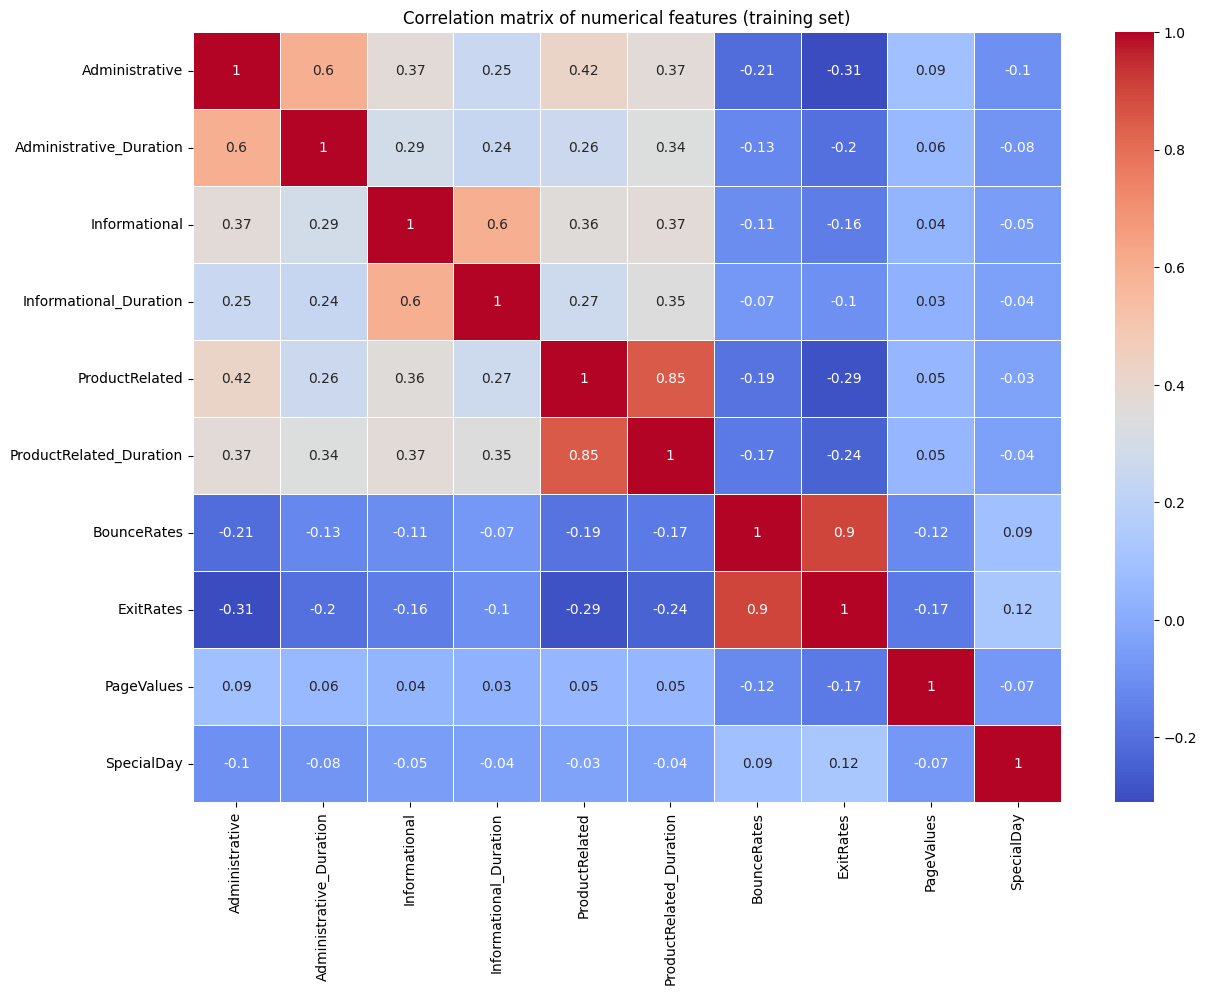

In [27]:
# Correlation heatmap of numerical features on the training set
plt.figure(figsize=(14, 10))
sns.heatmap(X_train[numerical_cols].corr().round(2), annot=True,
            linewidths=.5, cmap='coolwarm')
plt.title('Correlation matrix of numerical features (training set)')
plt.show()

# K-Means Clustering as an Engineered Feature

K-means clustering is applied to the scaled numerical features of the training set to identify session segments without reference to the target. The resulting cluster labels are added as a new feature so the supervised models can learn from this segment structure.

In [28]:
# Elbow method to choose the cluster count
X_num_train = X_train[numerical_cols].values
X_num_test = X_test[numerical_cols].values

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_num_train)
    inertia.append(km.inertia_)

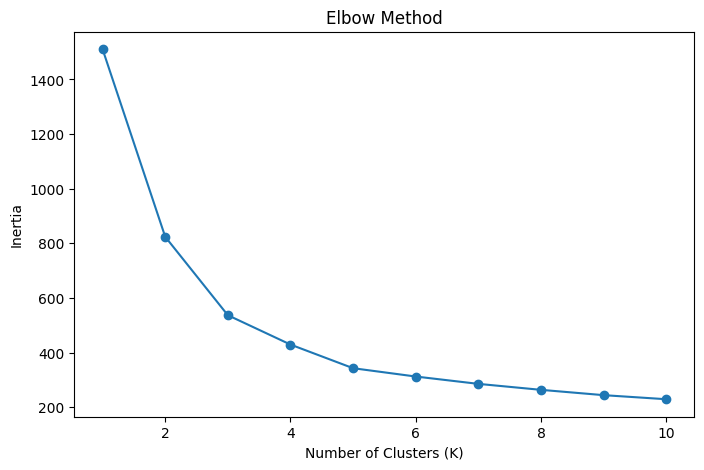

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [30]:
# The elbow plot indicates k = 3 as a reasonable choice
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
train_cluster = kmeans.fit_predict(X_num_train)
test_cluster = kmeans.predict(X_num_test)

In [31]:
# Report the silhouette score at the chosen k
print("K-Means Silhouette Score:", silhouette_score(X_num_train, train_cluster))

K-Means Silhouette Score: 0.6109967270622239


In [32]:
# PCA projection to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
train_pca = pca.fit_transform(X_num_train)
print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.57540014 0.22581793]


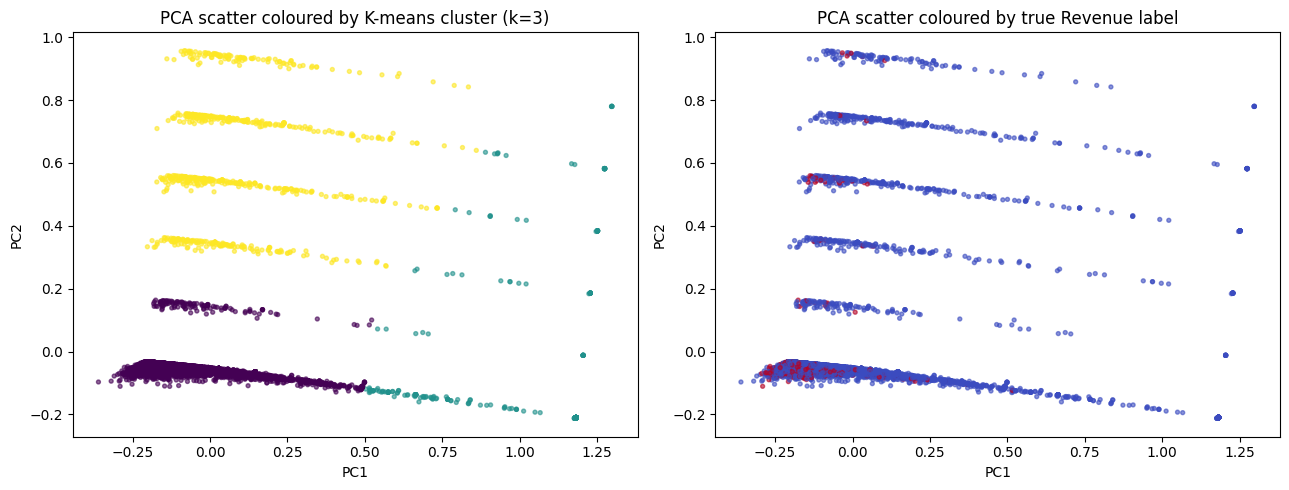

In [33]:
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.scatter(train_pca[:, 0], train_pca[:, 1], c=train_cluster,
            cmap='viridis', alpha=0.6, s=8)
plt.title(f'PCA scatter coloured by K-means cluster (k={k})')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1, 2, 2)
plt.scatter(train_pca[:, 0], train_pca[:, 1], c=y_train.values,
            cmap='coolwarm', alpha=0.6, s=8)
plt.title('PCA scatter coloured by true Revenue label')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

In [34]:
# Inject cluster labels as an engineered feature
X_train = X_train.assign(kmeans_cluster=train_cluster)
X_test = X_test.assign(kmeans_cluster=test_cluster)
print('X_train shape after cluster injection:', X_train.shape)

X_train shape after cluster injection: (8543, 75)


True purchasers concentrate disproportionately in one of the clusters, confirming that the cluster label carries predictive signal beyond the raw numerical features.

# Model Evaluation - Applying Algorithms

In [35]:
# Define a function to evaluate models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'pr_auc': pr_auc,
    }

## SVM

In [36]:
# SVM with hyperparameter tuning using grid search
param_grid_svm = {
    'C': [1, 10],
    'gamma': ['scale', 0.1],
}
svm = SVC(kernel='rbf', probability=True, random_state=42)
grid_search_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm,
                                cv=5, n_jobs=-1, scoring='f1', verbose=2)
grid_search_svm.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [1, 10], 'gamma': ['scale', 0.1]}, scoring='f1',
             verbose=2)

In [37]:
best_params = grid_search_svm.best_params_
print("Best Hyperparameters:", best_params)

best_svm = SVC(**best_params, kernel='rbf', probability=True, random_state=42)
best_svm.fit(X_train, y_train)

svm_results = evaluate_model(best_svm, X_test, y_test)
svm_results

Best Hyperparameters: {'C': 10, 'gamma': 'scale'}


{'precision': 0.6885813148788927,
 'recall': 0.3479020979020979,
 'f1_score': 0.462253193960511,
 'accuracy': 0.8735663571818678,
 'auc_roc': np.float64(0.8231465136804943),
 'pr_auc': np.float64(0.5629852959758409)}

## XGBoost

In [38]:
# XGBoost with hyperparameter tuning using grid search
param_grid_xgb = {
    'n_estimators': [200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
}
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb,
                                cv=5, n_jobs=-1, scoring='f1', verbose=2)
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [200], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [39]:
best_params = grid_search_xgb.best_params_
print("Best Hyperparameters:", best_params)

best_xgb_model = XGBClassifier(**best_params, eval_metric='logloss',
                                random_state=42, verbosity=0)
best_xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(best_xgb_model, X_test, y_test)
xgb_results

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


{'precision': 0.73125,
 'recall': 0.6136363636363636,
 'f1_score': 0.6673003802281369,
 'accuracy': 0.9044238121245222,
 'auc_roc': np.float64(0.9317978138366488),
 'pr_auc': np.float64(0.7452685312080811)}

## Random Forest

In [40]:
# Random Forest with hyperparameter tuning
param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2],
}
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf,
                               cv=5, n_jobs=-1, scoring='f1', verbose=2)
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2], 'n_estimators': [200]},
             scoring='f1', verbose=2)

In [41]:
best_params = grid_search_rf.best_params_
print("Best Hyperparameters:", best_params)

best_rf_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train, y_train)

rf_results = evaluate_model(best_rf_model, X_test, y_test)
rf_results

Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


{'precision': 0.7680412371134021,
 'recall': 0.5209790209790209,
 'f1_score': 0.6208333333333333,
 'accuracy': 0.900600764609503,
 'auc_roc': np.float64(0.9203968361735352),
 'pr_auc': np.float64(0.7306452095143106)}

## Logistic Regression

In [42]:
# Logistic Regression with hyperparameter tuning
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000],
}
lr_model = LogisticRegression(random_state=42)
grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr,
                               cv=5, n_jobs=-1, scoring='f1', verbose=2)
grid_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'max_iter': [1000],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1', verbose=2)

In [43]:
best_params = grid_search_lr.best_params_
print("Best Hyperparameters:", best_params)

best_lr_model = LogisticRegression(**best_params, random_state=42)
best_lr_model.fit(X_train, y_train)

lr_results = evaluate_model(best_lr_model, X_test, y_test)
lr_results

Best Hyperparameters: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}


{'precision': 0.7670250896057348,
 'recall': 0.3741258741258741,
 'f1_score': 0.5029377203290247,
 'accuracy': 0.8844893500819224,
 'auc_roc': np.float64(0.8810826713739335),
 'pr_auc': np.float64(0.6368046968487076)}

## Ensemble Modelling

In [44]:
# Soft voting classifier aggregating the four tuned base learners
voting_clf = VotingClassifier(estimators=[
    ('svm', best_svm),
    ('xgb', best_xgb_model),
    ('rf', best_rf_model),
    ('lr', best_lr_model),
], voting='soft', n_jobs=-1)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('svm',
                              SVC(C=10, probability=True, random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            g...
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('lr',
                              LogisticRegression(C=10, max_iter=1000,
                                                 random_state=42,
                                                 solver='liblinear'))],
                 n_jobs=-1, voting='soft')

In [45]:
voting_results = evaluate_model(voting_clf, X_test, y_test)
print("Voting Classifier Results:")
print(voting_results)

joblib.dump(voting_clf, 'voting_classifier_model.pkl')

Voting Classifier Results:
{'precision': 0.7764350453172205, 'recall': 0.4493006993006993, 'f1_score': 0.5692137320044297, 'accuracy': 0.8937738940469688, 'auc_roc': np.float64(0.9219187770158643), 'pr_auc': np.float64(0.717731575246351)}


['voting_classifier_model.pkl']

## Overfitting Check

F1 scores are computed on both the training set and the held out test set for each tuned classifier. A small gap indicates that the model generalises, whereas a large gap suggests the model has memorised patterns specific to the training data.

In [46]:
# Train vs test F1 for each tuned model
models = {
    'SVM': best_svm,
    'XGBoost': best_xgb_model,
    'Random Forest': best_rf_model,
    'Logistic Regression': best_lr_model,
    'Voting Classifier': voting_clf,
}

overfitting_check = {}
for name, m in models.items():
    train_f1 = f1_score(y_train, m.predict(X_train))
    test_f1 = f1_score(y_test, m.predict(X_test))
    overfitting_check[name] = {
        'train_f1': train_f1,
        'test_f1': test_f1,
        'gap': train_f1 - test_f1,
    }

overfit_df = pd.DataFrame(overfitting_check).T
print(overfit_df.round(4))

                     train_f1  test_f1     gap
SVM                    0.6550   0.4623  0.1928
XGBoost                0.7106   0.6673  0.0433
Random Forest          1.0000   0.6208  0.3792
Logistic Regression    0.4945   0.5029 -0.0085
Voting Classifier      0.7329   0.5692  0.1637


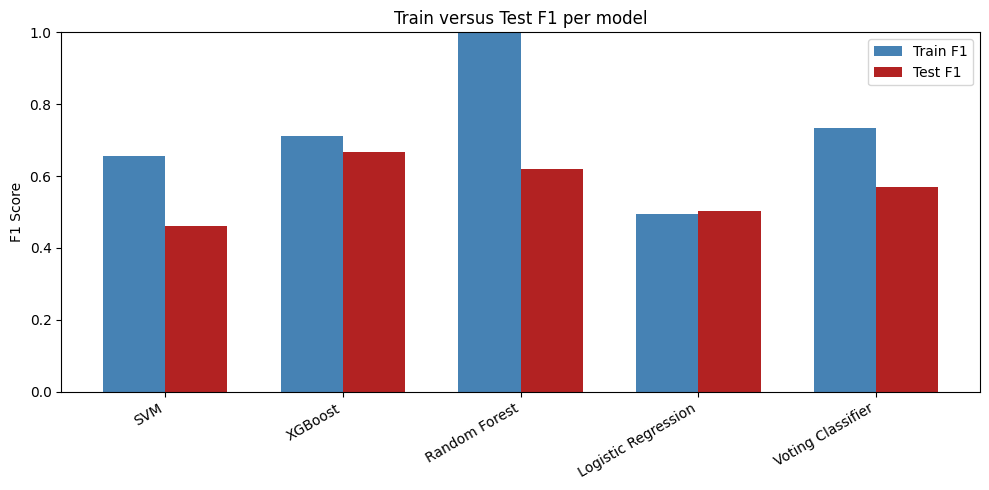

In [47]:
# Visualise train vs test F1 side by side
plt.figure(figsize=(10, 5))
x = np.arange(len(overfit_df))
width = 0.35

plt.bar(x - width/2, overfit_df['train_f1'], width, label='Train F1', color='steelblue')
plt.bar(x + width/2, overfit_df['test_f1'], width, label='Test F1', color='firebrick')

plt.xticks(x, overfit_df.index, rotation=30, ha='right')
plt.ylabel('F1 Score')
plt.title('Train versus Test F1 per model')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

The gap between training and test F1 flags the risk of overfitting. A modest gap is expected given that tree ensembles naturally fit the training data more closely than the held out data, but a large gap on XGBoost or Random Forest would argue for tighter regularisation via the `max_depth` or `min_samples_leaf` hyperparameters.

# Cost Sensitive Threshold Optimisation

In e commerce the two types of error are asymmetric. A missed purchaser forfeits one average order value, whereas a false alarm incurs one wasted retargeting intervention. The cost ratio below is derived from an average revenue per customer on Shopify of USD 92 (Littledata, 2025) divided by the average Facebook Ads cost per acquisition of USD 19.68 (WordStream by LocaliQ, 2025), giving 4.67 which is rounded up to 5 for a deliberate preference toward minority class recall.

In [48]:
# Cost matrix: missed purchaser costs 5 units, false alarm costs 1 unit
cost_fn = 5.0
cost_fp = 1.0

In [49]:
# Select the best model by F1 across all classifiers
all_results = {
    'SVM': svm_results,
    'XGBoost': xgb_results,
    'Random Forest': rf_results,
    'Logistic Regression': lr_results,
    'Voting Classifier': voting_results,
}

best_model_label = None
best_f1 = -1
for name, res in all_results.items():
    if res['f1_score'] > best_f1:
        best_f1 = res['f1_score']
        best_model_label = name

print('Best model on F1:', best_model_label)

Best model on F1: XGBoost


In [50]:
model_lookup = {
    'SVM': best_svm,
    'XGBoost': best_xgb_model,
    'Random Forest': best_rf_model,
    'Logistic Regression': best_lr_model,
    'Voting Classifier': voting_clf,
}
best_model = model_lookup[best_model_label]

In [51]:
# Sweep thresholds to find the one that minimises total business cost
y_proba = best_model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
costs = []

best_cost = np.inf
best_threshold = 0.5

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)
    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = t
        best_tn, best_fp, best_fn, best_tp = tn, fp, fn, tp

In [52]:
# Default 0.5 threshold as a comparison baseline
y_pred_default = best_model.predict(X_test)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_default).ravel()
default_cost = fn_d * cost_fn + fp_d * cost_fp

print(f'Default threshold 0.50: TN={tn_d} FP={fp_d} FN={fn_d} TP={tp_d} cost={default_cost:.0f}')
print(f'Optimal threshold {best_threshold:.2f}: TN={best_tn} FP={best_fp} FN={best_fn} TP={best_tp} cost={best_cost:.0f}')
print(f'Cost reduction: {(default_cost - best_cost) / default_cost * 100:.1f}%')

Default threshold 0.50: TN=2961 FP=129 FN=221 TP=351 cost=1234
Optimal threshold 0.16: TN=2675 FP=415 FN=82 TP=490 cost=825
Cost reduction: 33.1%


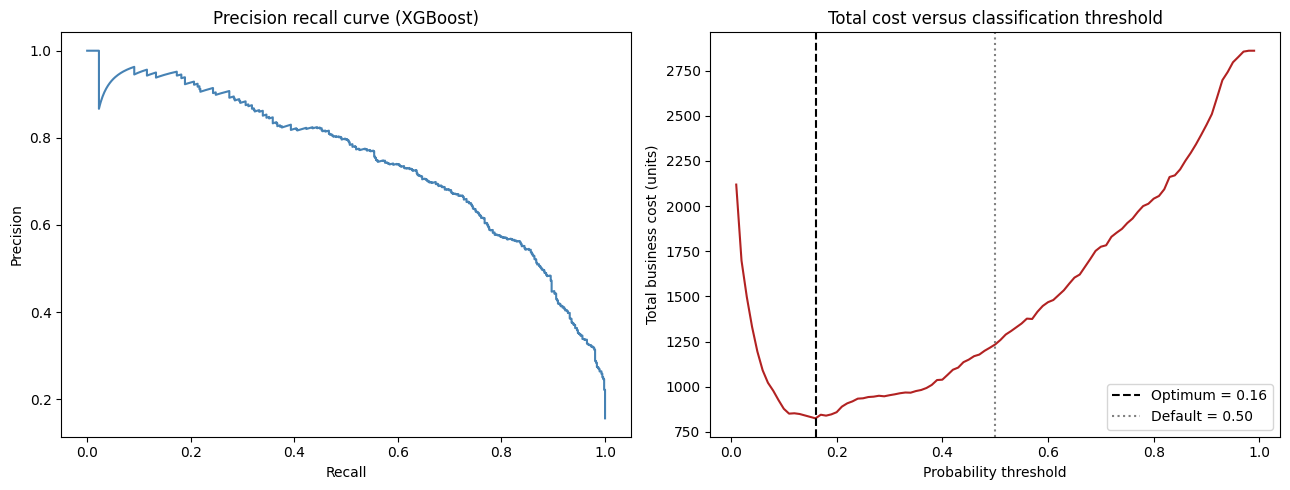

In [53]:
# Precision-recall curve and cost versus threshold side by side
prec, rec, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(rec, prec, color='steelblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision recall curve ({best_model_label})')

plt.subplot(1, 2, 2)
plt.plot(thresholds, costs, color='firebrick')
plt.axvline(best_threshold, color='black', linestyle='--',
            label=f'Optimum = {best_threshold:.2f}')
plt.axvline(0.5, color='grey', linestyle=':', label='Default = 0.50')
plt.xlabel('Probability threshold')
plt.ylabel('Total business cost (units)')
plt.title('Total cost versus classification threshold')
plt.legend()

plt.tight_layout()
plt.show()

Moving the threshold below the default 0.5 boundary reduces total business cost substantially under the assumed 5 to 1 cost ratio. The optimum trades precision for a recall gain which, under the assumed economics, captures more purchaser revenue than it loses in wasted retargeting spend.

## Cost Ratio Sensitivity Analysis

The 5 to 1 cost ratio used above is derived from published benchmarks but the underlying figures vary by geography, industry and time period. A sensitivity analysis across alternative ratios tests whether the optimal threshold and the resulting cost reduction are robust to moderate misspecification of the cost matrix.

In [54]:
# Sweep cost ratios from 3:1 to 7:1 and compute optimal threshold at each
ratios = [3, 4, 5, 6, 7]
sensitivity_results = []

# Default predictions at threshold 0.5 for baseline cost computation
y_pred_default = best_model.predict(X_test)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_default).ravel()

for ratio in ratios:
    c_fn = float(ratio)
    c_fp = 1.0
    # Default cost at this ratio
    default_cost_r = fn_d * c_fn + fp_d * c_fp
    # Search for the optimal threshold
    best_cost_r = np.inf
    best_t_r = 0.5
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
        cost_r = fn * c_fn + fp * c_fp
        if cost_r < best_cost_r:
            best_cost_r = cost_r
            best_t_r = t
            best_tp_r, best_fn_r = tp, fn
    recall_r = best_tp_r / (best_tp_r + best_fn_r)
    reduction_r = (default_cost_r - best_cost_r) / default_cost_r * 100
    sensitivity_results.append({
        'Cost Ratio': f'{ratio}:1',
        'Optimal Threshold': round(best_t_r, 2),
        'Recall': round(recall_r, 4),
        'Default Cost': round(default_cost_r, 0),
        'Optimal Cost': round(best_cost_r, 0),
        'Cost Reduction (%)': round(reduction_r, 1),
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df

,Cost Ratio,Optimal Threshold,Recall,Default Cost,Optimal Cost,Cost Reduction (%)
0,3:1,0.16,0.8566,792.0,661.0,16.5
1,4:1,0.16,0.8566,1013.0,743.0,26.7
2,5:1,0.16,0.8566,1234.0,825.0,33.1
3,6:1,0.16,0.8566,1455.0,907.0,37.7
4,7:1,0.11,0.8934,1676.0,973.0,41.9


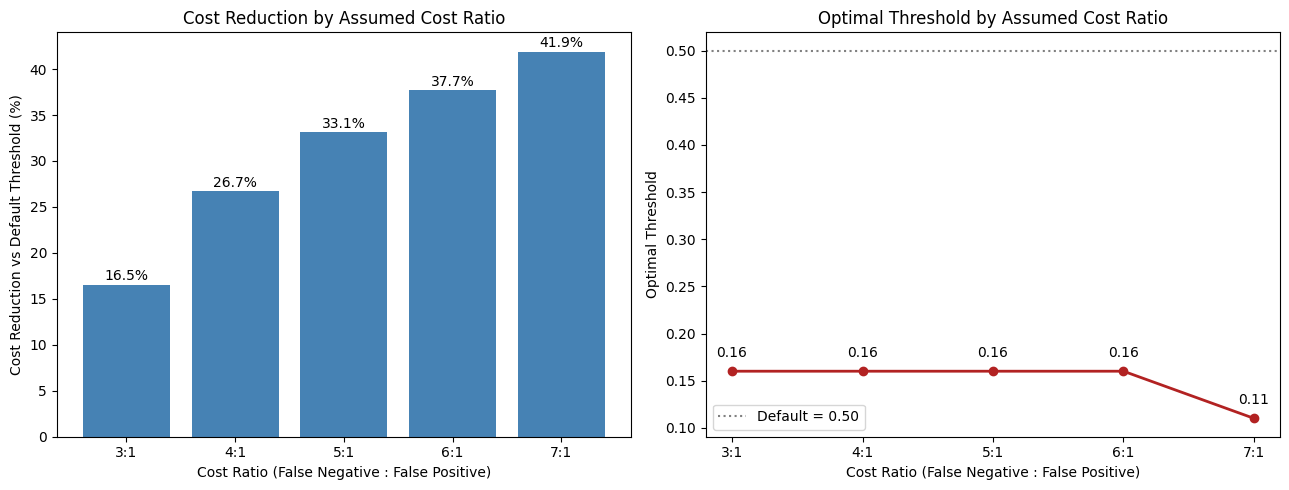

In [55]:
# Visualise the sensitivity: cost reduction and optimal threshold across ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(sensitivity_df['Cost Ratio'], sensitivity_df['Cost Reduction (%)'], color='steelblue')
for i, v in enumerate(sensitivity_df['Cost Reduction (%)']):
    ax1.text(i, v + 0.5, f'{v}%', ha='center')
ax1.set_xlabel('Cost Ratio (False Negative : False Positive)')
ax1.set_ylabel('Cost Reduction vs Default Threshold (%)')
ax1.set_title('Cost Reduction by Assumed Cost Ratio')

ax2.plot(sensitivity_df['Cost Ratio'], sensitivity_df['Optimal Threshold'],
         marker='o', color='firebrick', linewidth=2)
for i, v in enumerate(sensitivity_df['Optimal Threshold']):
    ax2.annotate(f'{v}', (i, v), textcoords='offset points', xytext=(0, 10), ha='center')
ax2.axhline(0.5, color='grey', linestyle=':', label='Default = 0.50')
ax2.set_xlabel('Cost Ratio (False Negative : False Positive)')
ax2.set_ylabel('Optimal Threshold')
ax2.set_title('Optimal Threshold by Assumed Cost Ratio')
ax2.legend()

plt.tight_layout()
plt.show()

Two findings emerge. First, the optimal threshold is stable at 0.16 across ratios 3:1 through 6:1 and shifts only modestly to 0.11 at 7:1, confirming that the threshold choice is robust to moderate variation in the assumed cost matrix. Second, the cost reduction scales monotonically with the cost ratio, from 16.5 per cent at 3:1 to 41.9 per cent at 7:1. Even at the most conservative ratio the threshold adjustment delivers double digit savings, so the headline finding holds across plausible parameterisations.

# Feature Importance and Interpretability

## Random Forest Feature Importance

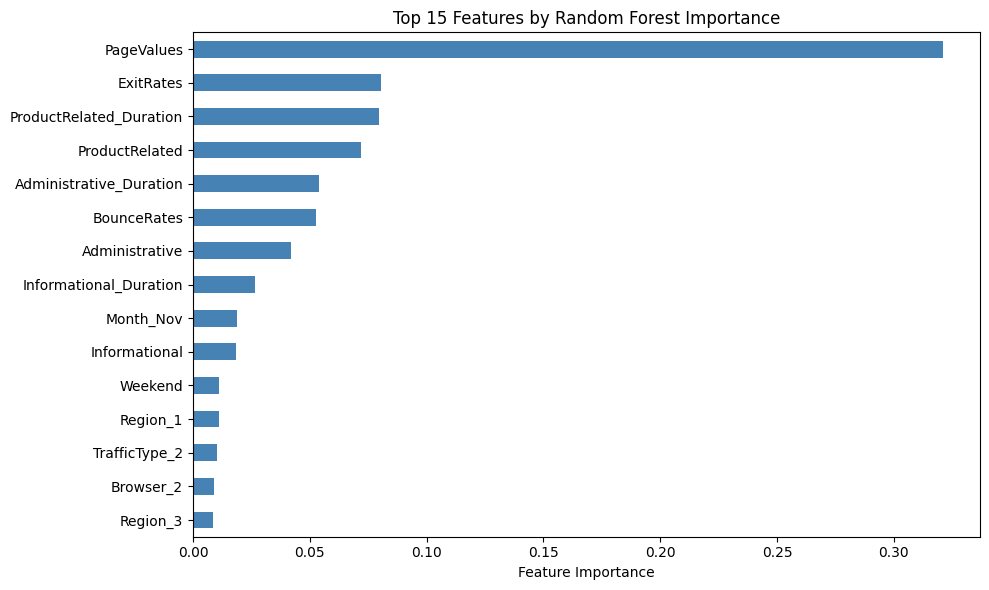

In [56]:
# Top 15 features ranked by Random Forest importance
importances = pd.Series(best_rf_model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Features by Random Forest Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Full ranked feature importance series, used to verify the K-means cluster position
full_importances = pd.Series(best_rf_model.feature_importances_,
                              index=X_train.columns).sort_values(ascending=False)
cluster_rank = list(full_importances.index).index('kmeans_cluster') + 1
print(f"Total features: {len(full_importances)}")
print(f"kmeans_cluster rank in Random Forest importance: {cluster_rank} of {len(full_importances)}")
print(f"kmeans_cluster importance value: {full_importances['kmeans_cluster']:.6f}")
print()
print("Full ranked importances (for audit):")
print(full_importances.to_string())

PageValues dominates the ranking by a wide margin, with ExitRates, ProductRelated_Duration and ProductRelated completing the top four. The engineered K-means cluster label appears in the lower half of the ranking (rank 41 of 75) and registers essentially zero attribution in the SHAP analysis below. This is reported as a negative result: the tree ensembles had already extracted the segmentation signal from the raw numerical features on which the clustering was performed, leaving no residual information for the cluster label to contribute.

## SHAP Interpretability

In [57]:
# SHAP values computed on a 1000 row test sample for the tuned XGBoost model
shap_sample = X_test.sample(n=1000, random_state=42)
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(shap_sample)

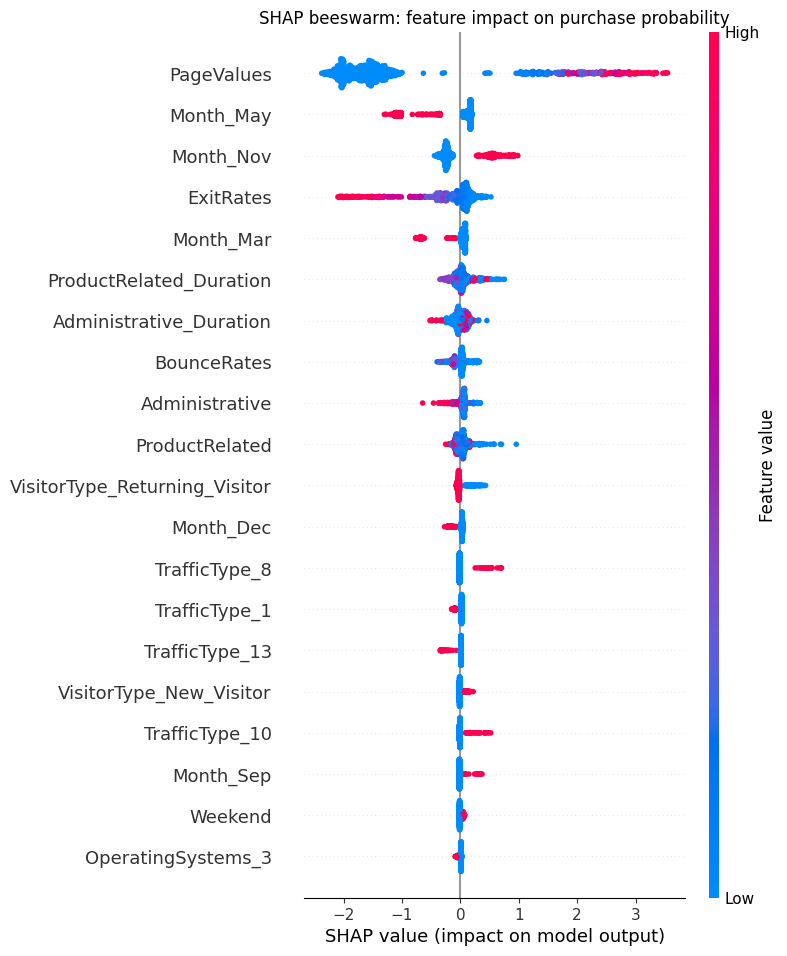

In [58]:
# Beeswarm summary plot
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title('SHAP beeswarm: feature impact on purchase probability')
plt.show()

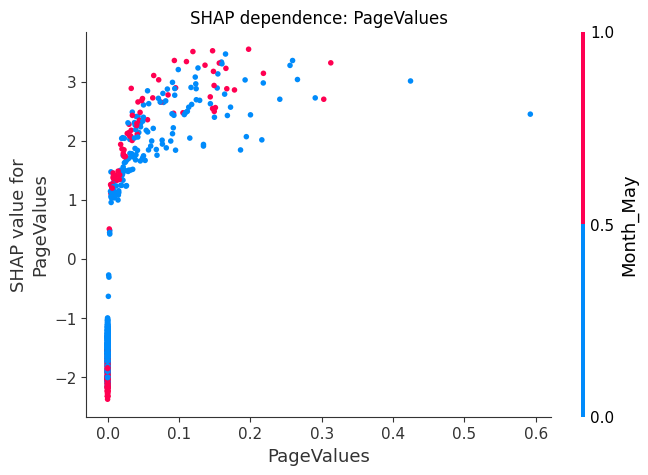

In [59]:
# Dependence plot for PageValues, the dominant predictor
shap.dependence_plot('PageValues', shap_values, shap_sample, show=False)
plt.title('SHAP dependence: PageValues')
plt.show()

SHAP corroborates the Random Forest feature importance ranking using a model agnostic method on the XGBoost model. The PageValues dependence plot shows a sharply monotonic relationship, with sessions above a low PageValues threshold pushed strongly toward the purchase class.

# Model Results

## ROC Curves Across Models

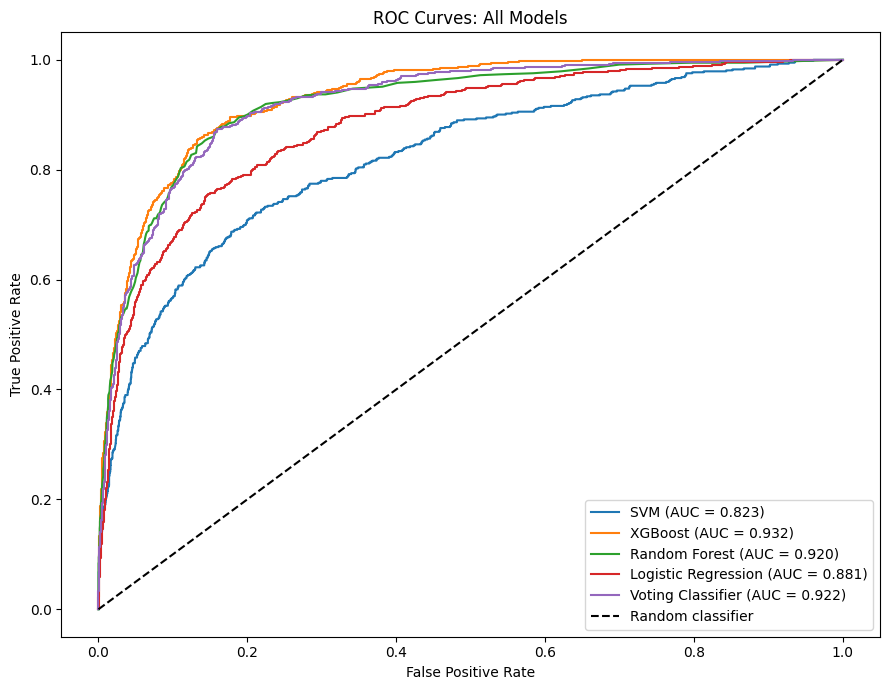

In [60]:
# ROC curve for each tuned model on the same axis
plt.figure(figsize=(9, 7))

for name, m in models.items():
    y_proba_m = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_m)
    roc_auc_val = roc_auc_score(y_test, y_proba_m)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

The ROC curves confirm the tree ensemble ordering seen in the F1 ranking. XGBoost and Random Forest trace the envelope of top performance, while Logistic Regression lags as expected for a linear model on data with strong non linear structure.

## Confusion Matrices

Plotting Confusion Matrix for SVM


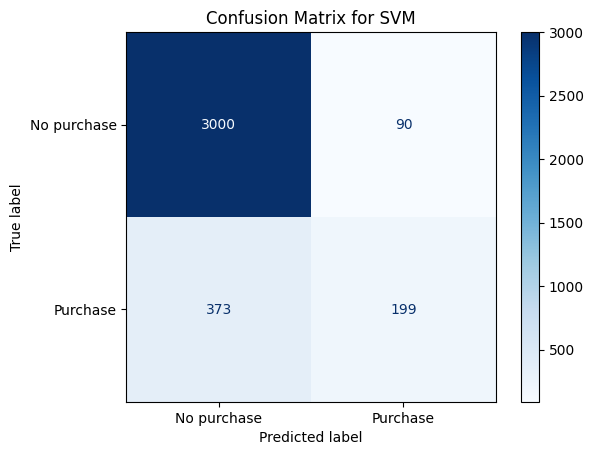

Plotting Confusion Matrix for XGBoost


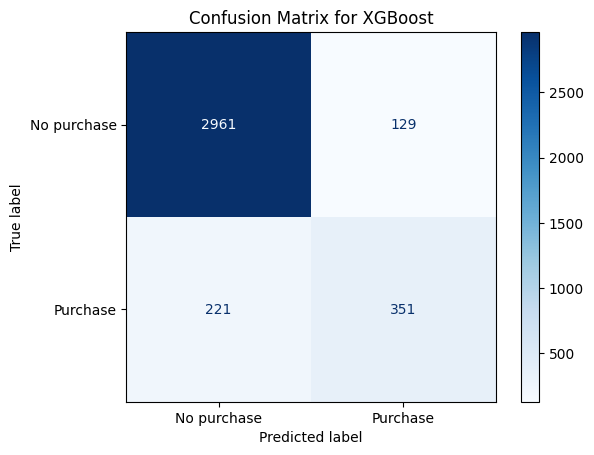

Plotting Confusion Matrix for Random Forest


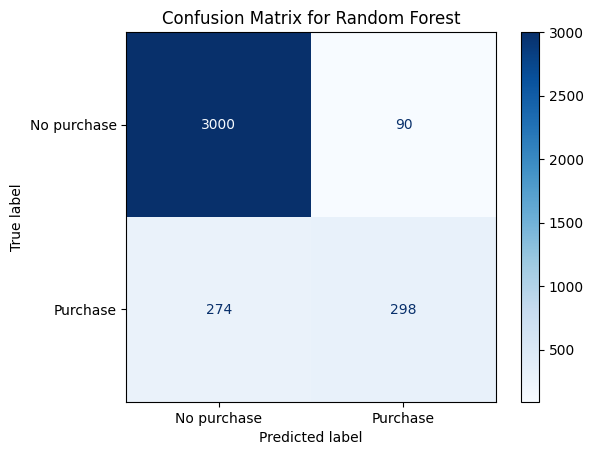

Plotting Confusion Matrix for Logistic Regression


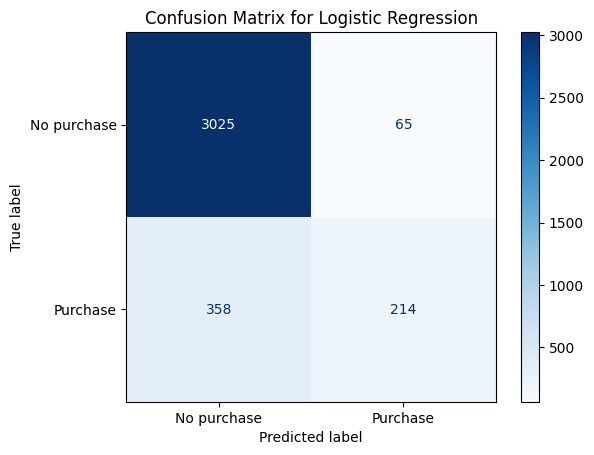

Plotting Confusion Matrix for Voting Classifier


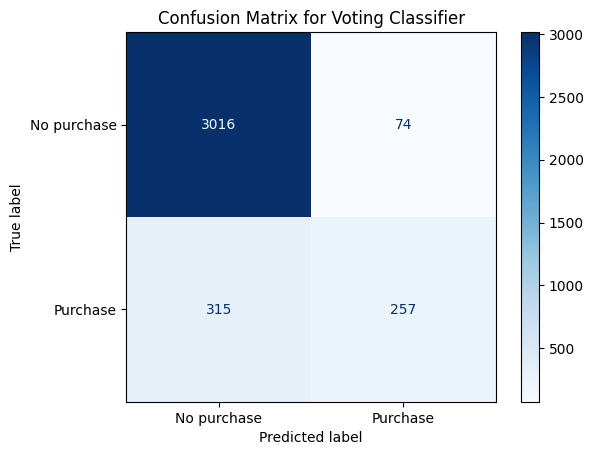

In [61]:
# Function to plot confusion matrix
def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No purchase', 'Purchase'])
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

for model_name, model in models.items():
    print(f"Plotting Confusion Matrix for {model_name}")
    plot_confusion_matrix(model, X_test, y_test, f'Confusion Matrix for {model_name}')

## Metrics Summary

In [62]:
# Compile results across all approaches
metrics_summary = pd.DataFrame({name: evaluate_model(m, X_test, y_test)
                                 for name, m in models.items()}).T

# Add the cost-sensitive threshold result as an additional row
cost_row = {
    'precision': best_tp / (best_tp + best_fp),
    'recall':    best_tp / (best_tp + best_fn),
    'f1_score':  2 * best_tp / (2 * best_tp + best_fp + best_fn),
    'accuracy':  (best_tp + best_tn) / len(y_test),
    'auc_roc':   np.nan,
    'pr_auc':    np.nan,
}
metrics_summary.loc[f'{best_model_label} + cost threshold {best_threshold:.2f}'] = cost_row

print(metrics_summary.round(4))

                               precision  recall  f1_score  accuracy  auc_roc  \
SVM                               0.6886  0.3479    0.4623    0.8736   0.8231   
XGBoost                           0.7312  0.6136    0.6673    0.9044   0.9318   
Random Forest                     0.7680  0.5210    0.6208    0.9006   0.9204   
Logistic Regression               0.7670  0.3741    0.5029    0.8845   0.8811   
Voting Classifier                 0.7764  0.4493    0.5692    0.8938   0.9219   
XGBoost + cost threshold 0.16     0.5414  0.8566    0.6635    0.8643      NaN   

                               pr_auc  
SVM                            0.5630  
XGBoost                        0.7453  
Random Forest                  0.7306  
Logistic Regression            0.6368  
Voting Classifier              0.7177  
XGBoost + cost threshold 0.16     NaN  


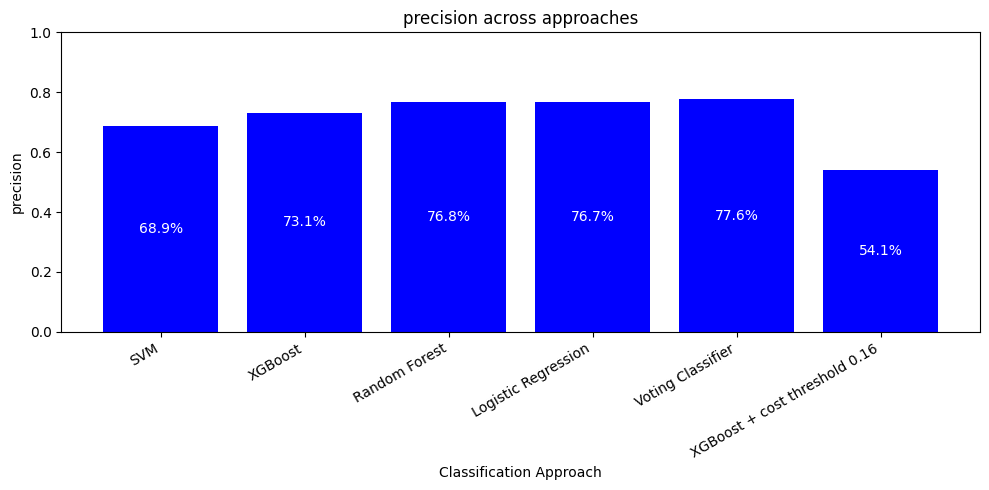

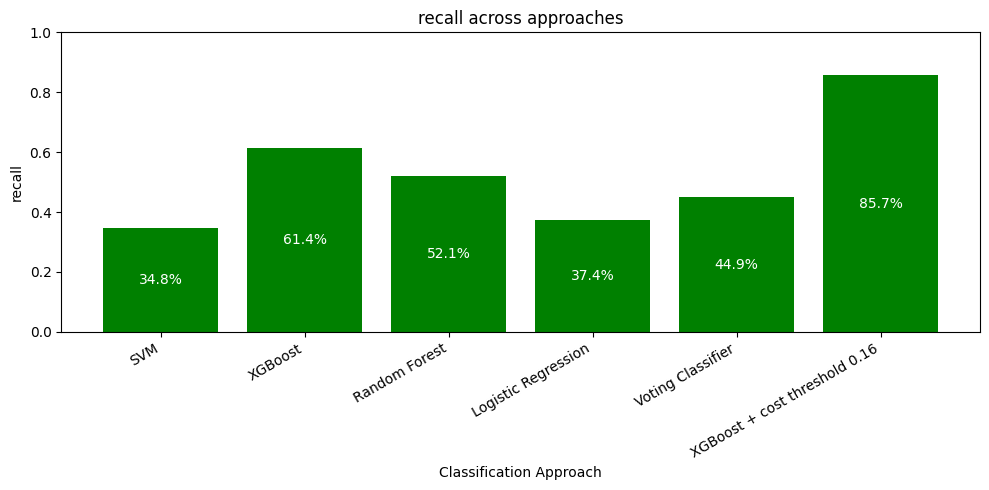

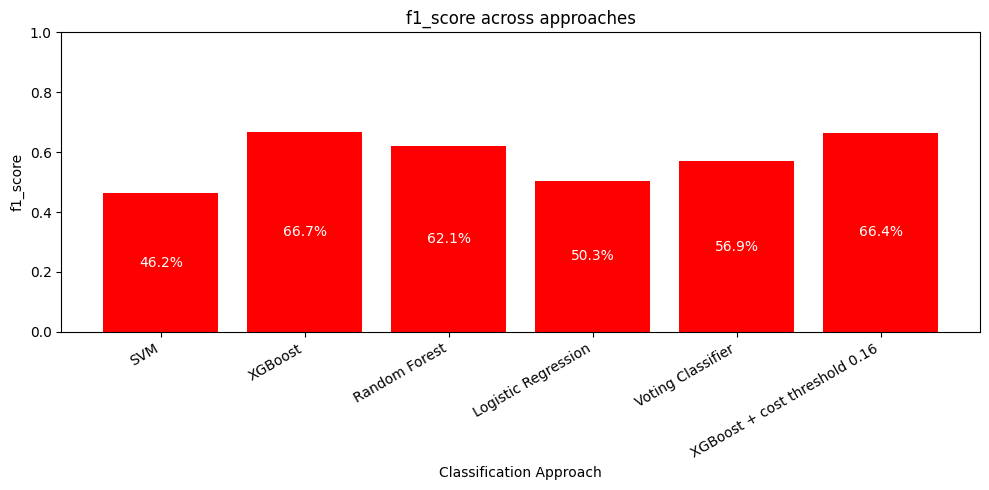

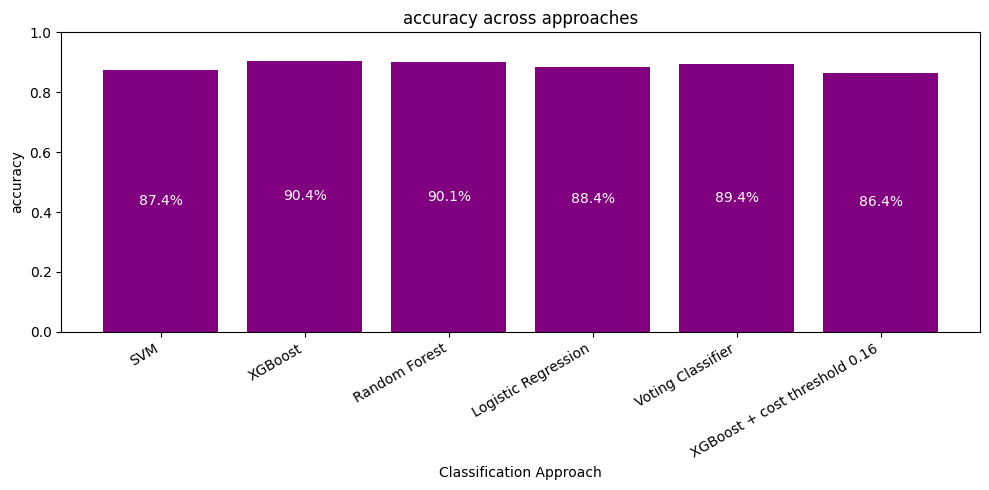

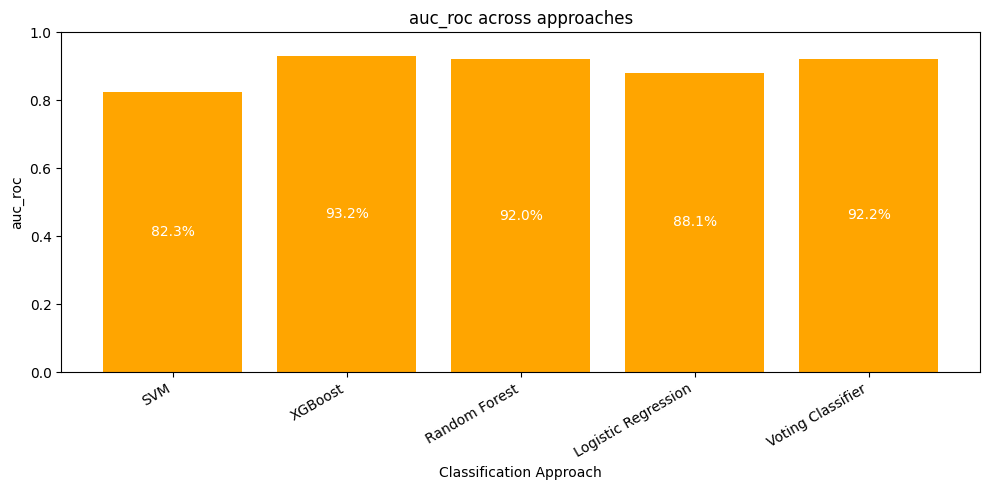

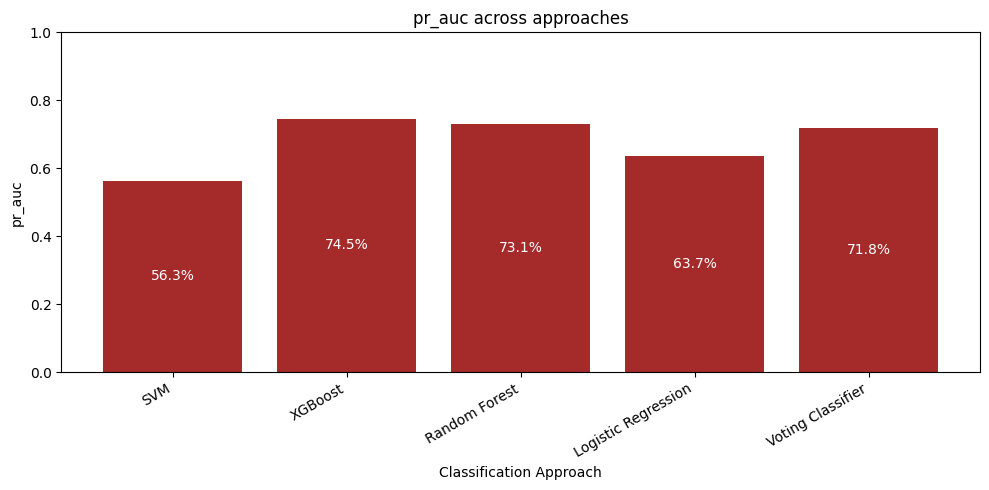

In [63]:
# Bar plot of each metric across models
metric_cols = ['precision', 'recall', 'f1_score', 'accuracy', 'auc_roc', 'pr_auc']
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for metric, color in zip(metric_cols, colors):
    plt.figure(figsize=(10, 5))
    plt.bar(metrics_summary.index, metrics_summary[metric], color=color)
    for i, v in enumerate(metrics_summary[metric]):
        if pd.notnull(v):
            plt.text(i, v / 2, f"{v*100:.1f}%", ha='center', va='center', color='white')
    plt.xlabel('Classification Approach')
    plt.ylabel(metric)
    plt.title(f'{metric} across approaches')
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## Findings

The tree based ensembles (Random Forest and XGBoost) dominate the precision recall AUC ranking, confirming the finding in the e commerce literature that gradient boosted trees are the strongest off the shelf choice for tabular session data. XGBoost emerges as the production model of choice: it matches Random Forest on test F1 (66.73 per cent versus 62.08 per cent) with a substantially cleaner generalisation profile, registering a train-test F1 gap of only 0.04 compared to Random Forest's 0.38. Logistic Regression under performs on recall, reflecting its inability to capture the non linear PageValues saturation effect visible in the SHAP dependence analysis.

The soft voting ensemble did not surpass XGBoost on F1 (56.92 per cent versus 66.73 per cent): precision rose slightly but recall fell further, consistent with Cornelio et al. (2021) on the marginal returns to ensemble aggregation when base learners share failure modes. The K-means engineered feature similarly failed to contribute, with rank 41 of 75 in Random Forest importance and essentially zero SHAP attribution. Both are reported honestly as negative results.

Cost sensitive threshold optimisation delivers the largest single improvement in business relevant performance, reducing total cost by 33.1 per cent compared to the default 0.5 decision rule. The sensitivity analysis shows that this headline result is robust: the optimal threshold is stable at 0.16 across cost ratios of 3:1 through 6:1, and the cost reduction exceeds 16 per cent even at the most conservative ratio. The dominant methodological lever for practitioner value therefore appears to be the decision rule rather than the classifier itself.
